Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [1]:
import random
random.seed(1234)

In [2]:
# Download dataset
import tensorflow as tf
import tensorflow_datasets as tfds

raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

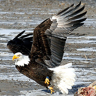
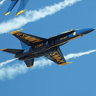
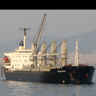
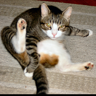

In [3]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

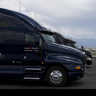
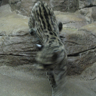
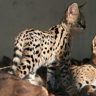
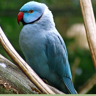

In [4]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)


tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [5]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32) / 255.0

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [6]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000, reshuffle_each_iteration=False) # Shuffle the dataset before splitting

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [7]:
BATCH_SIZE = 32 # You can adjust this based on your GPU memory

# 1. Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Batch the validation data
val_data = val_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Batch the test data (if you plan to evaluate later)
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Baseline Model

In [8]:
import matplotlib.pyplot as plt

def plot_history(history, model_name="Model"):
    """
    Plots the training and validation accuracy and loss.
    """
    # Extract metrics from the history object [cite: 230]
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{model_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{model_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [9]:
from tensorflow.keras import layers, models

def build_baseline_model(input_shape, num_classes):
    model = models.Sequential([
        # 1. First Convolutional Block
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 2. Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 3. Third Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 4. Flatten and Dense Layers for Classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [10]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

baseline = build_baseline_model(img_shape, num_classes)
baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.2226 - loss: 2.0879 - val_accuracy: 0.3490 - val_loss: 1.6599
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4292 - loss: 1.5393 - val_accuracy: 0.5030 - val_loss: 1.3729
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5270 - loss: 1.3088 - val_accuracy: 0.5250 - val_loss: 1.3261
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.6048 - loss: 1.1039 - val_accuracy: 0.5620 - val_loss: 1.2389
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6725 - loss: 0.9109 - val_accuracy: 0.5460 - val_loss: 1.3069
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7429 - loss: 0.7510 - val_accuracy: 0.5590 - val_loss: 1.3024
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7870 - loss: 0.6038 - val_accuracy: 0.5630 - val_loss: 1.4393
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8569 - loss: 0.4176 - val_ac

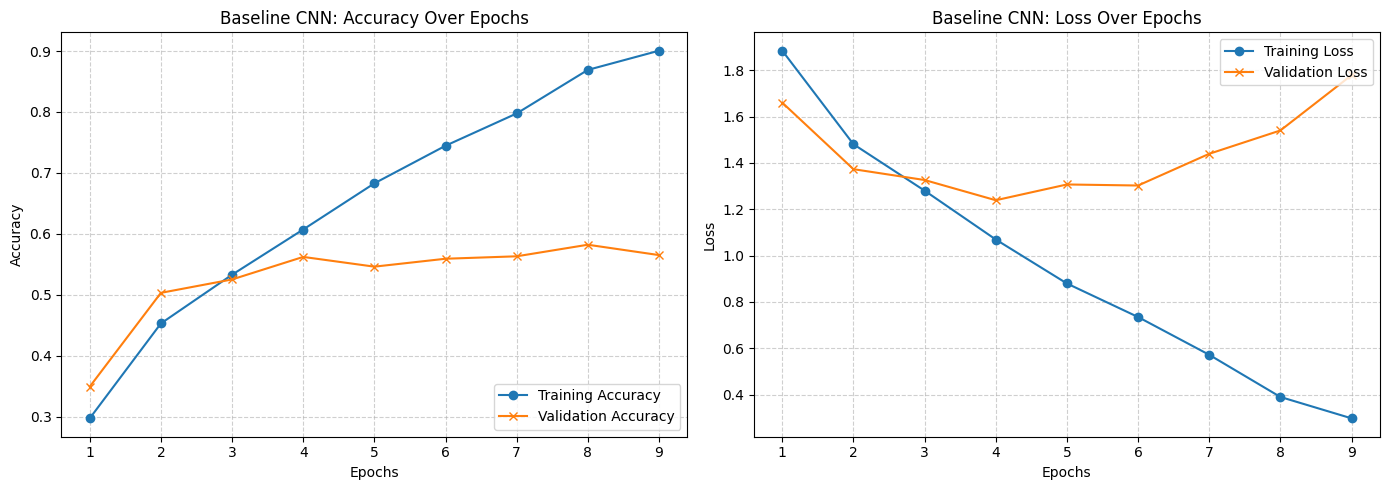

In [11]:
baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# Callbacks for tuning
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]
history = baseline.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks
)

plot_history(history, model_name="Baseline CNN")

In [12]:
test_loss, test_accuracy = baseline.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5455 - loss: 1.2833
Test Accuracy: 55.54%
Test Loss: 1.2701


# Model Training

In [13]:
from tensorflow.keras import layers, models, regularizers


def residual_block(x, filters, stride=1):
    shortcut = x
    
    # First convolution in the block
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same', 
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Second convolution
    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    
    # If dimensions changed (due to stride), adjust the shortcut connection
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Data Augmentation (Internal to the model for simplicity)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    
    # 2. Initial Convolutional Layer
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # 3. Stacked Residual Blocks (Increasing complexity)
    x = residual_block(x, 64, stride=2) # Downsample to 1/2 size
    x = residual_block(x, 64)
    x = layers.Dropout(0.5)(x)
    
    x = residual_block(x, 128, stride=2) # Downsample to 1/4 size
    x = residual_block(x, 128)
    
    # 4. Global Average Pooling (Regularizes and reduces parameters)
    x = layers.GlobalAveragePooling2D()(x)
    
    # 5. Output Layer
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

# Extract info for initialization
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

model = build_model(img_shape, num_classes)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy', # Used because labels are one-hot encoded
    metrics=['accuracy']
)

# Callbacks for tuning
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step - accuracy: 0.1932 - loss: 2.3760 - val_accuracy: 0.0950 - val_loss: 2.4858 - learning_rate: 1.0000e-04
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.2682 - loss: 1.9692 - val_accuracy: 0.1290 - val_loss: 2.4102 - learning_rate: 1.0000e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - accuracy: 0.2835 - loss: 1.9094 - val_accuracy: 0.1550 - val_loss: 2.4546 - learning_rate: 1.0000e-04
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - accuracy: 0.3093 - loss: 1.8611 - val_accuracy: 0.1920 - val_loss: 2.2325 - learning_rate: 1.0000e-04
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.3392 - loss: 1.8181 - val_accuracy: 0.3150 - val_loss: 1.8013 - learning_rate: 1.0000e-04
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - accuracy: 0.3481 - loss: 1.7624 - val_accuracy: 0.3700 - val_loss: 1.7424 - learning_rate: 1.0000e-04
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 11